In [8]:
import pandas as pd
import spacy
from spacy.lang.en import English
import re
import numpy as np

# from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

In [4]:
from gensim.models import Word2Vec

In [5]:
# Load the dataset
data_path = "train.csv"  # Update the path accordingly
tweets_df = pd.read_csv(data_path)

In [6]:
# Define the SpaCy tokenizer
nlp = English()


def spacy_tokenizer(text):
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text, re.I | re.A)
    text = text.lower()
    tokens = nlp(text)
    tokens = [
        token.text for token in tokens if not token.is_stop and len(token.text) > 2
    ]
    return tokens


# Tokenize the text data
tweets_df["tokens"] = tweets_df["text"].apply(spacy_tokenizer)

In [10]:
# Train a Word2Vec model
word2vec_model = Word2Vec(
    sentences=tweets_df["tokens"], vector_size=100, window=5, min_count=2, workers=4
)


# Function to convert tweets into a mean vector
def tweet_to_mean_vector(tweet_tokens):
    vector = np.zeros(
        word2vec_model.vector_size
    )  # Initialize a zero vector of the same length as the embeddings
    valid_tokens = [token for token in tweet_tokens if token in word2vec_model.wv]
    if len(valid_tokens) > 0:
        vector = sum(word2vec_model.wv[token] for token in valid_tokens)
        vector /= len(valid_tokens)
    return vector


# Apply the function to each tweet
X = tweets_df["tokens"].apply(tweet_to_mean_vector)

In [11]:
# Convert X to a list and then stack to form a NumPy array
X = np.vstack(X.values)

# Extract targets
y = tweets_df["target"].values

# Split the data into training and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [15]:
# Define the model
model_nn = Sequential(
    [
        Dense(
            128, activation="relu", input_dim=word2vec_model.vector_size
        ),  # input dimension = size of Word2Vec vectors
        Dropout(0.5),
        Dense(64, activation="relu"),
        Dropout(0.5),
        Dense(1, activation="sigmoid"),
    ]
)

# Compile the model
model_nn.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy", "Precision", "Recall"],
)

# Model summary
model_nn.summary()

/opt/anaconda3/envs/metal/lib/python3.11/site-packages/keras/src/layers/core/dense.py:86: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │        12,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,249 (83.00 KB)

 Trainable params: 21,249 (83.00 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# Train the model
history_nn = model_nn.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=2,
)

Epoch 1/10
191/191 - 3s - 15ms/step - Precision: 0.4672 - Recall: 0.1087 - accuracy: 0.5629 - loss: 0.6843 - val_Precision: 0.3878 - val_Recall: 0.0293 - val_accuracy: 0.5666 - val_loss: 0.6755
Epoch 2/10
191/191 - 2s - 8ms/step - Precision: 0.5035 - Recall: 0.1358 - accuracy: 0.5703 - loss: 0.6763 - val_Precision: 0.4551 - val_Recall: 0.1094 - val_accuracy: 0.5647 - val_loss: 0.6695
Epoch 3/10
191/191 - 2s - 8ms/step - Precision: 0.5167 - Recall: 0.1884 - accuracy: 0.5747 - loss: 0.6725 - val_Precision: 0.4430 - val_Recall: 0.0539 - val_accuracy: 0.5680 - val_loss: 0.6675
Epoch 4/10
191/191 - 2s - 8ms/step - Precision: 0.5036 - Recall: 0.1892 - accuracy: 0.5706 - loss: 0.6721 - val_Precision: 0.5129 - val_Recall: 0.3359 - val_accuracy: 0.5811 - val_loss: 0.6673
Epoch 5/10
191/191 - 2s - 8ms/step - Precision: 0.5005 - Recall: 0.2052 - accuracy: 0.5696 - loss: 0.6729 - val_Precision: 0.4444 - val_Recall: 0.0431 - val_accuracy: 0.5693 - val_loss: 0.6661
Epoch 6/10
191/191 - 2s - 8ms/step

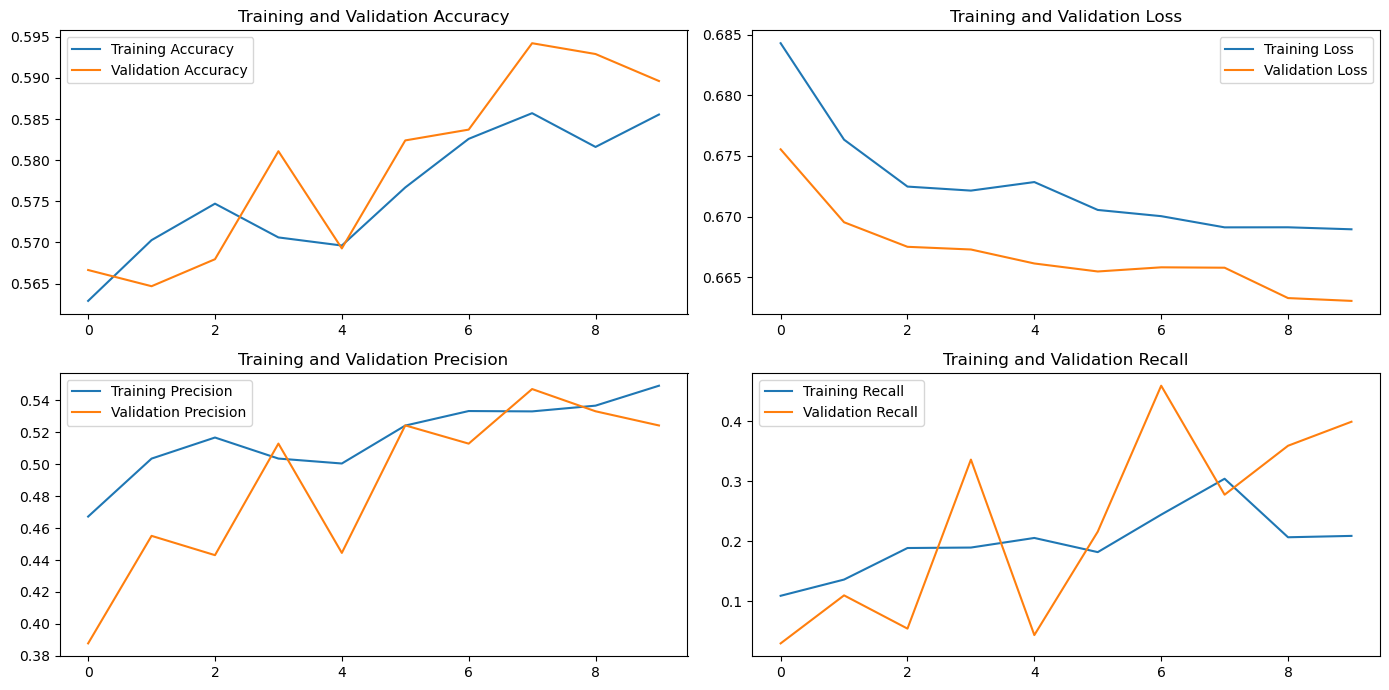

In [18]:
import matplotlib.pyplot as plt


# Function to plot the history graphs for accuracy, loss, precision, and recall
def plot_history(history):
    plt.figure(figsize=(14, 7))
    plt.subplot(2, 2, 1)
    plt.plot(history.history["accuracy"], label="Training Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.title("Training and Validation Accuracy")
    plt.legend()

    plt.subplot(2, 2, 2)
    plt.plot(history.history["loss"], label="Training Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title("Training and Validation Loss")
    plt.legend()

    plt.subplot(2, 2, 3)
    plt.plot(history.history["Precision"], label="Training Precision")
    plt.plot(history.history["val_Precision"], label="Validation Precision")
    plt.title("Training and Validation Precision")
    plt.legend()

    plt.subplot(2, 2, 4)
    plt.plot(history.history["Recall"], label="Training Recall")
    plt.plot(history.history["val_Recall"], label="Validation Recall")
    plt.title("Training and Validation Recall")
    plt.legend()

    plt.tight_layout()
    plt.show()


# Plotting the history for our basic neural network
plot_history(history_nn)

### RNN Model

In [19]:
from tensorflow.keras.layers import SimpleRNN

# Define the RNN model
model_rnn = Sequential(
    [
        SimpleRNN(
            50, return_sequences=True, input_shape=(1, 100)
        ),  # Input shape needed (batch_size, timesteps, input_dim)
        Dropout(0.5),
        SimpleRNN(50),
        Dropout(0.5),
        Dense(1, activation="sigmoid"),
    ]
)

# Compile the model
model_rnn.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy", "Precision", "Recall"],
)

# Model summary
model_rnn.summary()

/opt/anaconda3/envs/metal/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 1, 50)          │         7,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1, 50)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,651 (49.42 KB)

 Trainable params: 12,651 (49.42 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
# Reshape the input data
X_train_rnn = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test_rnn = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

In [21]:
history_rnn = model_rnn.fit(
    X_train_rnn,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test_rnn, y_test),
    verbose=2,
)

Epoch 1/10
191/191 - 7s - 38ms/step - Precision: 0.5022 - Recall: 0.0862 - accuracy: 0.5698 - loss: 0.6832 - val_Precision: 0.3898 - val_Recall: 0.0354 - val_accuracy: 0.5653 - val_loss: 0.6760
Epoch 2/10
191/191 - 3s - 18ms/step - Precision: 0.5284 - Recall: 0.1632 - accuracy: 0.5770 - loss: 0.6777 - val_Precision: 0.4779 - val_Recall: 0.1002 - val_accuracy: 0.5699 - val_loss: 0.6742
Epoch 3/10
191/191 - 3s - 18ms/step - Precision: 0.5032 - Recall: 0.1514 - accuracy: 0.5703 - loss: 0.6783 - val_Precision: 0.4956 - val_Recall: 0.0863 - val_accuracy: 0.5732 - val_loss: 0.6734
Epoch 4/10
191/191 - 3s - 18ms/step - Precision: 0.5250 - Recall: 0.1564 - accuracy: 0.5759 - loss: 0.6759 - val_Precision: 0.5217 - val_Recall: 0.1109 - val_accuracy: 0.5778 - val_loss: 0.6721
Epoch 5/10
191/191 - 3s - 18ms/step - Precision: 0.5358 - Recall: 0.1770 - accuracy: 0.5796 - loss: 0.6722 - val_Precision: 0.5455 - val_Recall: 0.1202 - val_accuracy: 0.5824 - val_loss: 0.6703
Epoch 6/10
191/191 - 3s - 18ms

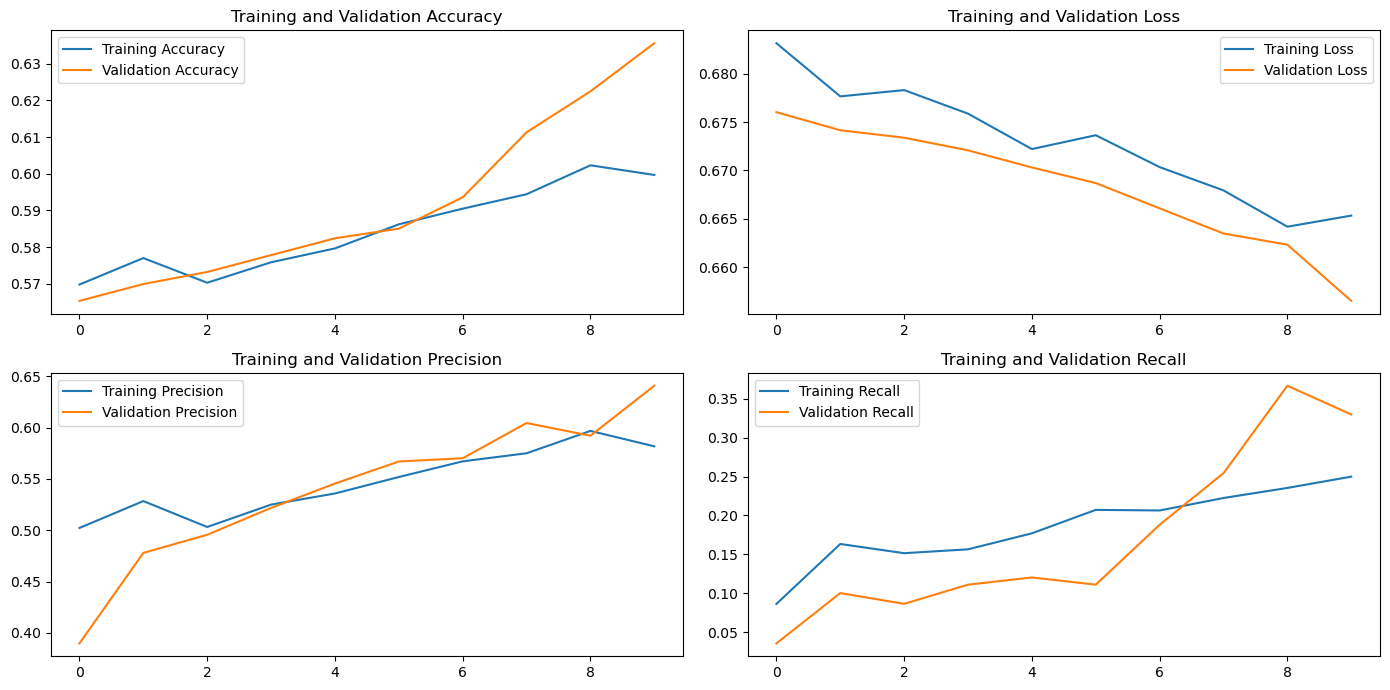

In [22]:
# Plotting the history for the RNN model
plot_history(history_rnn)

In [23]:
from tensorflow.keras.layers import LSTM

# Define the LSTM model
model_lstm = Sequential(
    [
        LSTM(
            50, return_sequences=True, input_shape=(1, 100)
        ),  # Input shape required for LSTM (batch_size, timesteps, input_dim)
        Dropout(0.5),
        LSTM(50),
        Dropout(0.5),
        Dense(1, activation="sigmoid"),
    ]
)

# Compile the model
model_lstm.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy", "Precision", "Recall"],
)

# Model summary
model_lstm.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 50)          │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1, 50)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,451 (197.07 KB)

 Trainable params: 50,451 (197.07 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
history_lstm = model_lstm.fit(
    X_train_rnn,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test_rnn, y_test),
    verbose=2,
)

Epoch 1/10
191/191 - 6s - 29ms/step - Precision: 0.3913 - Recall: 0.0034 - accuracy: 0.5686 - loss: 0.6868 - val_Precision: 0.0000e+00 - val_Recall: 0.0000e+00 - val_accuracy: 0.5739 - val_loss: 0.6825
Epoch 2/10
191/191 - 2s - 12ms/step - Precision: 0.4107 - Recall: 0.0088 - accuracy: 0.5678 - loss: 0.6820 - val_Precision: 0.3729 - val_Recall: 0.0339 - val_accuracy: 0.5640 - val_loss: 0.6779
Epoch 3/10
191/191 - 2s - 12ms/step - Precision: 0.4797 - Recall: 0.1129 - accuracy: 0.5654 - loss: 0.6766 - val_Precision: 0.4734 - val_Recall: 0.1371 - val_accuracy: 0.5673 - val_loss: 0.6734
Epoch 4/10
191/191 - 2s - 12ms/step - Precision: 0.5135 - Recall: 0.2037 - accuracy: 0.5741 - loss: 0.6738 - val_Precision: 0.5040 - val_Recall: 0.1957 - val_accuracy: 0.5752 - val_loss: 0.6704
Epoch 5/10
191/191 - 2s - 12ms/step - Precision: 0.5235 - Recall: 0.2551 - accuracy: 0.5793 - loss: 0.6726 - val_Precision: 0.5097 - val_Recall: 0.2835 - val_accuracy: 0.5785 - val_loss: 0.6689
Epoch 6/10
191/191 - 2

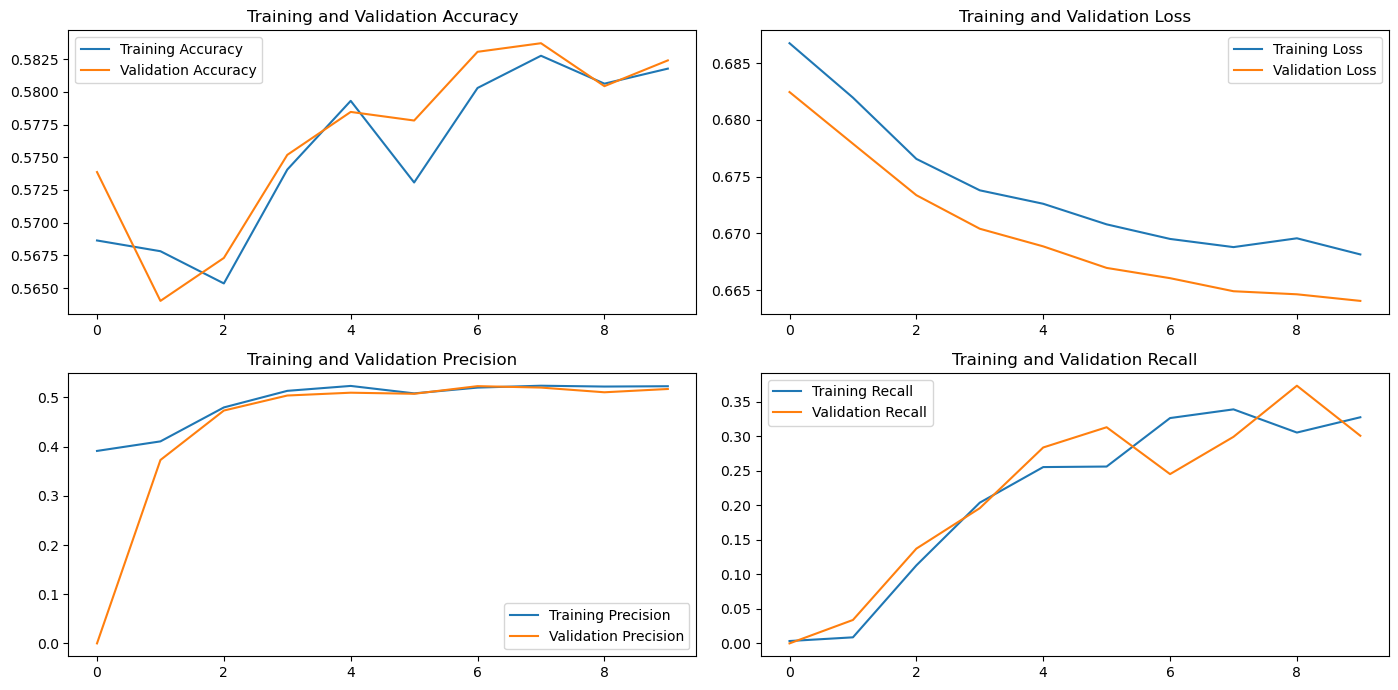

In [25]:
# Plotting the history for the LSTM model
plot_history(history_lstm)

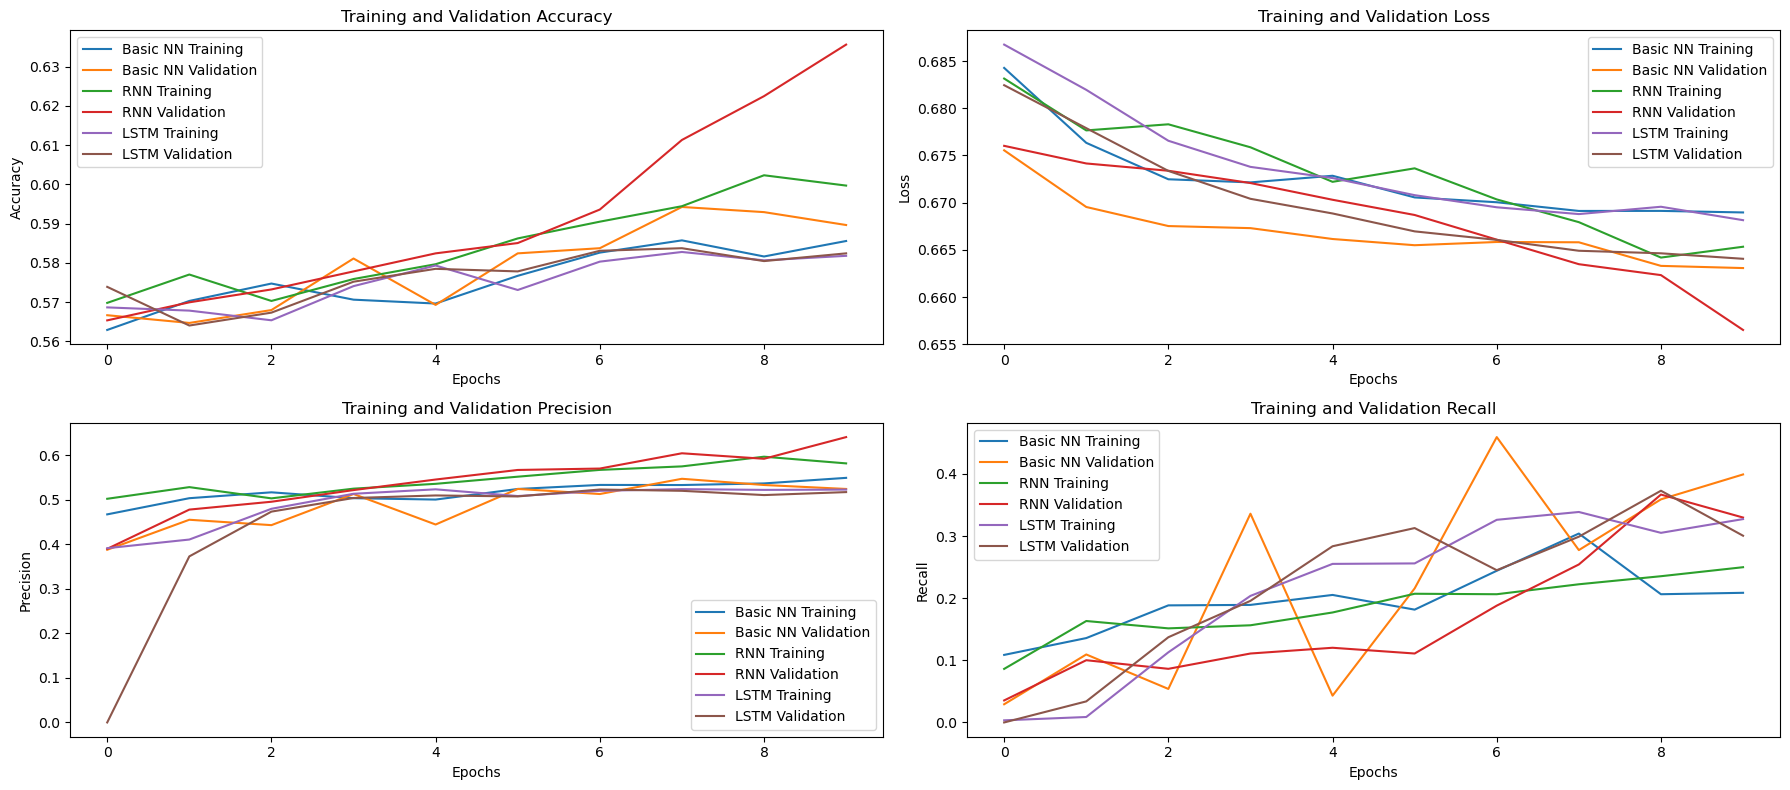

In [27]:
# Example of how to compare performance metrics
def compare_models(histories, model_names):
    metrics = ["accuracy", "loss", "Precision", "Recall"]
    plt.figure(figsize=(18, 8))

    for i, metric in enumerate(metrics):
        plt.subplot(2, 2, i + 1)
        for history, name in zip(histories, model_names):
            plt.plot(history.history[metric], label=f"{name} Training")
            plt.plot(history.history[f"val_{metric}"], label=f"{name} Validation")
        plt.title(f"Training and Validation {metric.capitalize()}")
        plt.xlabel("Epochs")
        plt.ylabel(metric.capitalize())
        plt.legend()

    plt.tight_layout()
    plt.show()


# Comparing all models
compare_models([history_nn, history_rnn, history_lstm], ["Basic NN", "RNN", "LSTM"])